In [1]:
from math import *
import numpy as np

from astropy import units as u
from astropy.coordinates import SkyCoord

In [2]:
pos = '23:35:50.060 +54:51:13.00'
c = SkyCoord(pos, unit=(u.hourangle, u.deg))
print(c.ra.degree, c.dec.degree)

pos_oc = '23:33:11.12 +54:55:06.1'
c_oc = SkyCoord(pos_oc, unit=(u.hourangle, u.deg))

353.9585833333333 54.853611111111114


In [3]:
def angular_distance(ra,dec,RA,DEC):
    return 0# напишите свою функцию

In [4]:
def tangential_coordinates(ra,dec,RA,DEC):
    ksi = 0# напишите выражене для ksi
    eta = 0# напишите выражение для eta
    return ksi,eta

#### Небольшая подсказка...

$ \begin{bmatrix} x \\y\\z \end{bmatrix} = \frac{1}{\sqrt{1+\xi^2+\eta^2}}\begin{bmatrix} -sin(\alpha_0)&-cos(\alpha_0)  sin(\delta_0)&cos(\alpha_0)cos(\delta_0)\\ cos(\alpha_0)&-sin(\alpha_0)sin(\delta_0)& sin(\alpha_0)cos(\delta_0) \\ 0&cos(\delta_0)&sin(\delta_0) \end{bmatrix}\begin{bmatrix} \xi \\ \eta \\ 1 \end{bmatrix} $

In [5]:
def equatorial_coordinates(ksi,eta,RA,Dec):
    x,y,z = np.dot(np.array([[1,1,1],# замените единички корректными соотношениями
                             [1,1,1],
                             [1,1,1]]),
                   np.array([ksi,eta,1]))/sqrt(1+ksi*ksi+eta*eta)
    ra = atan2(y,x)
    dec = atan2(z,sqrt(x*x+y*y))
    if(ra<0):
        ra+=2*pi
    return ra,dec

### Как меняется масштаб изображения в плоскости тангенциальных координат? Если точность измерений составляет 0.01 arcsec, то при каком угловом расстоянии от оптического центра изменения масштаба будут значимыми?

In [11]:
#соорудим сетку тангенциальных координат
hfov = 20.0#половина исследуемого поля в градусах
Np = 11 # у нас 11 точек
ksi = np.linspace(-hfov,hfov,Np)
eta = np.linspace(-hfov,hfov,Np)
ksi,eta = np.meshgrid(ksi,eta)# создаем сетку
# print(ksi[7,3],eta[7,3])

In [7]:
delta_ksi,delta_eta = np.ones((Np, Np)),np.ones((Np, Np))# массивы для хранения информации о сдвигах
step = 2*hfov/(Np-1)# шаг сетки
print(step)

4.0


In [8]:
for i in range(Np-1):
    for j in range(Np-1):
        ra1,dec1 = equatorial_coordinates(radians(ksi[i,j]),radians(eta[i,j]),0,0)
        ra2, dec2 = equatorial_coordinates(radians(ksi[i, j+1]), radians(eta[i, j+1]), 0, 0)
        rho = angular_distance(ra1,dec1,ra2,dec2)
        delta_ksi[i,j] = (step - rho)
        ra2, dec2 = equatorial_coordinates(radians(ksi[i+1, j ]), radians(eta[i+1, j ]), 0, 0)
        rho = angular_distance(ra1, dec1, ra2, dec2)
        delta_eta[i, j] = (step - rho)

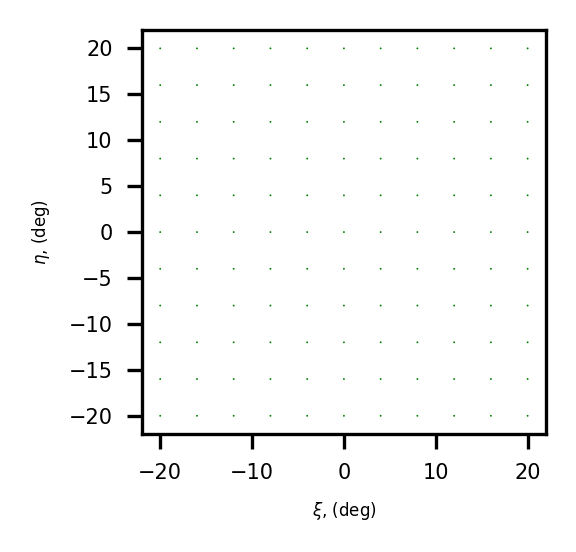

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(2,2), dpi=300)
ax.set_aspect('equal')
plt.scatter(ksi,eta, c='green', s=0.2,   edgecolors='none')
ax.xaxis.set_tick_params(labelsize=5)
ax.yaxis.set_tick_params(labelsize=5)
ax.set_xlabel('$\\xi$, (deg)', fontsize=4)
ax.set_ylabel('$\\eta$, (deg)', fontsize=4)
plt.tight_layout()

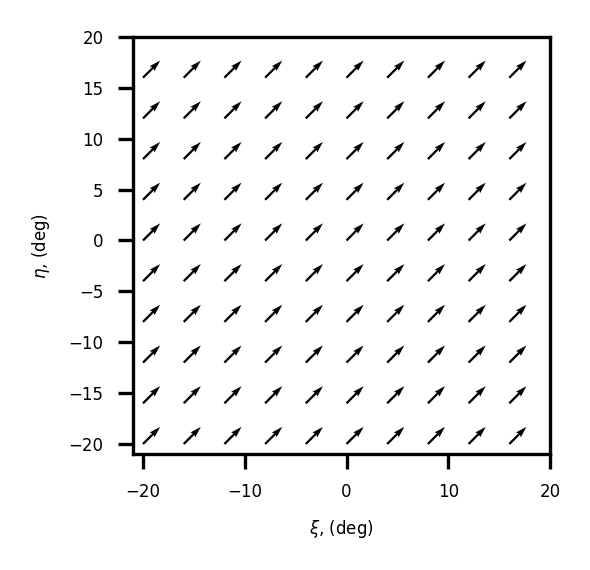

In [21]:
scv = '%5.1f deg'%(sqrt(delta_ksi.max()**2+delta_eta.max()**2))
fig, ax = plt.subplots(figsize=(2.5,2), dpi=300, tight_layout=True)
ax.set_aspect('equal')
q = plt.quiver(ksi,eta,delta_ksi,delta_eta)
ax.quiverkey(q, X=0, Y=21, U=sqrt(delta_ksi.max()**2+delta_eta.max()**2),
                 label=scv, labelpos='S', angle = 00, labelsep = 0.05,fontproperties={'size': 4})
ax.xaxis.set_tick_params(labelsize=4)
ax.yaxis.set_tick_params(labelsize=4)
ax.set_xlim(-21,20)
ax.set_ylim(-21,20)
ax.set_xlabel('$\\xi$, (deg)', fontsize=4)
ax.set_ylabel('$\\eta$, (deg)', fontsize=4)
plt.tight_layout()